In [ ]:
#!/usr/bin/env python
# coding: utf-8
#
# 01_download_5xfad_and_annotate.py
# [VERIFIED: Alzheimers2.py, GEO download RECONSTRUCTED using NCBI's
# documented FTP convention]
#
# INPUT:  none (downloads from NCBI GEO)
# OUTPUT: snRNA_fully_annotated.h5ad
#
# PAUSES FOR A MANUAL STEP: uploads a CSV to the Allen Institute's
# MapMyCells web tool (no public API exists for this) and waits for you to
# place the downloaded results back in this directory before continuing.
# Rerun this script after that step; already-completed work is skipped.

import os
import numpy as np
import pandas as pd
import scanpy as sc
import glob
import zipfile

sc.settings.verbosity = 2
sc.set_figure_params(dpi=150, figsize=(7, 6), frameon=True, facecolor="white")

if os.path.exists("snRNA_fully_annotated.h5ad"):
    print("snRNA_fully_annotated.h5ad already exists, nothing to do.")
    raise SystemExit(0)

import pysoupx  # noqa: F401  -- required for DecontX pre-clustering step below
import pydecontx

folder = "GSE309604_RAW/"
replicates = {
    "5mo_rep1": "GSM9270315_GFP_5mo_1.h5",
    "5mo_rep2": "GSM9270316_GFP_5mo_2.h5",
    "9mo_rep1": "GSM9270321_GFP_9mo_1.h5",
    "9mo_rep2": "GSM9270322_GFP_9mo_2.h5",
}

# --- Download raw GEO supplementary files (NCBI's standard FTP convention:
# last 3 digits of the accession replaced with 'nnn') ---
os.makedirs(folder, exist_ok=True)
import requests

for label, fname in replicates.items():
    full_path = os.path.join(folder, fname)
    if os.path.exists(full_path):
        print(f"Already present, skipping download: {fname}")
        continue
    gsm_id = fname.split("_")[0]
    gsm_dir = gsm_id[:-3] + "nnn"
    url = f"https://ftp.ncbi.nlm.nih.gov/geo/samples/{gsm_dir}/{gsm_id}/suppl/{fname}"
    print(f"Downloading {fname} from {url} ...")
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        with open(full_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=1 << 20):
                f.write(chunk)
    print(f"  Saved {full_path}")

print("=== VERIFYING REPLICATE FILE PATHS ===")
for label, fname in replicates.items():
    full_path = os.path.join(folder, fname)
    status = "Found" if os.path.exists(full_path) else "MISSING"
    print(f"{status} | {label}: {fname}")

# --- DecontX ambient RNA removal, per replicate ---
cleaned_adatas = []
for label, fname in replicates.items():
    path = os.path.join(folder, fname)
    print(f"\nRunning DecontX on {label} ({fname})...")
    adata = sc.read_10x_h5(path)
    adata.var_names_make_unique()
    adata.obs_names_make_unique()

    adata_prep = adata.copy()
    sc.pp.normalize_total(adata_prep, target_sum=1e4)
    sc.pp.log1p(adata_prep)
    sc.pp.highly_variable_genes(adata_prep, n_top_genes=2000)
    sc.pp.pca(adata_prep, mask_var="highly_variable")
    sc.pp.neighbors(adata_prep)
    sc.tl.leiden(adata_prep, key_added="decont_cluster")
    adata.obs["decont_cluster"] = adata_prep.obs["decont_cluster"]

    res = pydecontx.decontx(adata, z="decont_cluster")
    adata.layers["raw_counts"] = adata.X.copy()
    adata.layers["decontX_counts"] = res.decontx_counts.T
    adata.X = res.decontx_counts.T.copy()
    adata.obs["contamination"] = res.contamination
    print(f"   Mean contamination for {label}: {adata.obs['contamination'].mean():.2%}")

    adata.obs["replicate"] = label
    adata.obs["age"] = "5mo" if "5mo" in label else "9mo"
    cleaned_adatas.append(adata)

adata = sc.concat(cleaned_adatas, join="outer")
adata.obs_names_make_unique()
print(f"\nCombined: {adata.n_obs} cells x {adata.n_vars} genes")

# --- QC metrics + author's exact filtering thresholds ---
adata.var["mt"] = adata.var_names.str.startswith("mt-") | adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

print(f"Cells before filtering: {adata.n_obs}")
sc.pp.filter_cells(adata, min_genes=500)
sc.pp.filter_cells(adata, max_genes=5000)
sc.pp.filter_cells(adata, max_counts=25000)
adata = adata[adata.obs["pct_counts_mt"] <= 5.0].copy()
sc.pp.filter_genes(adata, min_cells=3)
print(f"Cells remaining after QC filters: {adata.n_obs}; genes remaining: {adata.n_vars}")

# --- Doublet removal (Scrublet) ---
sc.pp.scrublet(adata, batch_key="replicate")
doublet_counts = adata.obs["predicted_doublet"].value_counts()
print(f"Detected doublets: {(doublet_counts.get(True, 0) / adata.n_obs) * 100:.2f}%")
adata = adata[~adata.obs["predicted_doublet"]].copy()
adata.write("adata_decontX_qc_filtered.h5ad", compression=None)

# --- Sex check ---
female_genes = [g for g in ["Xist"] if g in adata.var_names]
male_genes = [g for g in ["Ddx3y", "Eif2s3y", "Uty"] if g in adata.var_names]
sex_df = pd.DataFrame(index=adata.obs["replicate"].unique())
for g in female_genes + male_genes:
    sex_df[g] = [adata[adata.obs["replicate"] == rep, g].X.mean() for rep in sex_df.index]
print("=== Sex marker expression per replicate ===")
print(sex_df)
adata.obs["sex"] = "Male"  # all replicates confirmed male via Y-chromosome markers

# --- Normalize + log1p, preserving raw counts ---
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

# --- HVG selection + PCA ---
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="replicate")
adata.raw = adata
sc.pp.scale(adata, max_value=10, zero_center=False)
sc.tl.pca(adata)
adata.write("snRNA_post_pca.h5ad")

# --- Neighbors, UMAP, Leiden ---
adata = sc.read_h5ad("snRNA_post_pca.h5ad")
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)
# NOTE (known limitation): no random_state set on this call in the original
# code -- not guaranteed to reproduce identical cluster boundaries on rerun.
adata.write("snRNA_clustered_umap.h5ad")

# --- Export per-cluster mean expression for MapMyCells ---
matrix = adata.layers["counts"] if "counts" in adata.layers else adata.X
cluster_ids = adata.obs["leiden"].cat.categories
mean_expr_df = pd.DataFrame(index=adata.var_names)
for cid in cluster_ids:
    cell_mask = (adata.obs["leiden"] == cid).values
    mean_expr_df[f"Cluster_{cid}"] = np.array(matrix[cell_mask].mean(axis=0)).flatten()
mean_expr_df.to_csv("leiden_cluster_means_mapmycells.csv")
print(
    "\nACTION REQUIRED: upload leiden_cluster_means_mapmycells.csv to the "
    "Allen Institute's MapMyCells web tool (10x Whole Mouse Brain taxonomy) "
    "at https://knowledge.brain-map.org/mapmycells/process/ and place the "
    "downloaded results (.zip or .csv) in this directory or ~/Downloads, "
    "then rerun this script."
)

# --- Load MapMyCells results and map onto clusters ---
import fnmatch


def find_matches(directory, pattern):
    if not os.path.isdir(directory):
        return []
    return [os.path.join(directory, f) for f in os.listdir(directory)
            if fnmatch.fnmatch(f.lower(), pattern.lower())]


zip_matches = (
    find_matches(".", "*mapmycells*.zip")
    + find_matches(os.path.expanduser("~/Downloads"), "*mapmycells*.zip")
    + find_matches(".", "*10xwholemousebrain*.zip")
    + find_matches(os.path.expanduser("~/Downloads"), "*10xwholemousebrain*.zip")
)
csv_matches = (
    find_matches(".", "*mapmycells*.csv")
    + find_matches(os.path.expanduser("~/Downloads"), "*10xwholemousebrain*.csv")
    + find_matches(".", "*hierarchicalmapping*.csv")
)
target_csv = None
if zip_matches:
    with zipfile.ZipFile(zip_matches[0], "r") as z:
        for filename in z.namelist():
            if filename.endswith(".csv"):
                z.extract(filename, path=".")
                target_csv = filename
                break
elif csv_matches:
    target_csv = csv_matches[0]
if target_csv is None or not os.path.exists(target_csv):
    raise FileNotFoundError(
        "Could not locate MapMyCells CSV/ZIP. Complete the ACTION REQUIRED "
        "step above, then rerun this script."
    )

df_map = pd.read_csv(target_csv, comment="#")
df_map["leiden_id"] = df_map["cell_id"].astype(str).str.replace("Cluster_", "")
class_map = dict(zip(df_map["leiden_id"], df_map["class_name"]))
subclass_map = dict(zip(df_map["leiden_id"], df_map["subclass_name"]))
adata.obs["cell_type_class"] = adata.obs["leiden"].map(class_map)
adata.obs["cell_type_subclass"] = adata.obs["leiden"].map(subclass_map)

adata.write("snRNA_fully_annotated.h5ad")
print("Complete: saved snRNA_fully_annotated.h5ad. Next: 02_download_wt_atlas_raw.py")

In [ ]:
#!/usr/bin/env python
# coding: utf-8
#
# 02_download_wt_atlas_raw.py
# [REVERSE-ENGINEERED AGAINST A KNOWN TARGET, exact match confirmed: this
# reconstruction was tested and reproduces the original file's cell count
# exactly -- 121,516 cells, matching to the last cell. IMPORTANT: the choice
# to exclude "WMB-10Xv3-Isocortex-2" was arrived at by working backward from
# the known target count and the original file's recorded region-acronym
# breakdown (see NOTE below), not derived independently from the paper's
# stated methods, which only describe "hippocampal formation and isocortex"
# in general terms and don't name specific Allen Atlas matrix files. This
# confirms the reconstruction reproduces the original file precisely; it
# does not confirm the original file's own selection was itself fully
# correct per the stated methodology -- that's a separate, unresolved
# question this exercise can't answer.]
#
# INPUT:  none (downloads from the Allen Institute's public S3 bucket)
# OUTPUT: ./data/abc_atlas_wt_glia_raw.h5ad
#
# Requires: pip install "abc_atlas_access[notebooks] @ git+https://github.com/alleninstitute/abc_atlas_access.git"
# No AWS account needed -- this is a public S3 bucket.
#
# Confirmed: WMB-10Xv3 expression matrices are split by region, so this only
# downloads the 3 region files needed (HPF, Isocortex-1, Isocortex-2), not
# the full ~176 GB atlas.
#
# VERIFY: this prints the unique feature_matrix_label and class values found
# before filtering -- confirm they match what's used below, since exact
# label strings can shift slightly between Allen data releases.

import os
from pathlib import Path

if os.path.exists("./data/abc_atlas_wt_glia_raw.h5ad"):
    print("./data/abc_atlas_wt_glia_raw.h5ad already exists, nothing to do.")
    raise SystemExit(0)

import anndata as ad
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

download_base = Path("./data/abc_atlas_cache")
abc_cache = AbcProjectCache.from_cache_dir(download_base)

print("Downloading cell metadata...")
cell_metadata = abc_cache.get_metadata_dataframe(
    directory="WMB-10X", file_name="cell_metadata_with_cluster_annotation"
)

print(f"\nUnique feature_matrix_label values present:\n{sorted(cell_metadata['feature_matrix_label'].unique())}")
print(f"\nUnique class values present:\n{sorted(cell_metadata['class'].unique())}")
print(
    "\nVERIFY the two filters below match what you see printed above -- "
    "region/class label strings occasionally change between Allen data releases."
)

target_matrix_labels = ["WMB-10Xv3-HPF", "WMB-10Xv3-Isocortex-1"]
# NOTE: "WMB-10Xv3-Isocortex-2" was tested and excluded -- including it
# produced 250,665 cells vs. the original file's 121,516. HPF alone
# (100,259 cells) plus Isocortex-1 alone (21,257 cells) sums to exactly
# 121,516, matching the original file precisely. Isocortex-2 was
# confirmed not part of the original selection.
non_neuronal_classes = [c for c in cell_metadata["class"].unique()
                         if any(k in c for k in ["Astro-Epen", "OPC-Oligo", "Vascular", "Immune"])]
print(f"\nMatched non-neuronal class labels: {non_neuronal_classes}")
if not non_neuronal_classes:
    raise RuntimeError(
        "No class labels matched Astro-Epen/OPC-Oligo/Vascular/Immune -- "
        "inspect the printed class list above and adjust the matching logic."
    )

region_class_mask = (
    cell_metadata["feature_matrix_label"].isin(target_matrix_labels)
    & cell_metadata["class"].isin(non_neuronal_classes)
)
filtered_cells = cell_metadata[region_class_mask]
print(f"\nFiltered to {len(filtered_cells):,} cells across {target_matrix_labels}")
if len(filtered_cells) == 0:
    raise RuntimeError("Zero cells matched -- check the filters above against the printed unique values.")

# --- Download only the needed regional expression matrices, subset by cell
# ID immediately (backed mode), discard the rest ---
subsets = []
for matrix_label in target_matrix_labels:
    print(f"\nDownloading/locating {matrix_label}/raw (this can take a while the first time)...")
    file_path = abc_cache.get_file_path(directory="WMB-10Xv3", file_name=f"{matrix_label}/raw")
    adata_region = ad.read_h5ad(file_path, backed="r")
    target_ids = filtered_cells.loc[filtered_cells["feature_matrix_label"] == matrix_label, "cell_label"]
    adata_region_sub = adata_region[adata_region.obs_names.isin(target_ids)].to_memory()
    print(f"  {matrix_label}: kept {adata_region_sub.n_obs:,} of {adata_region.n_obs:,} cells")
    subsets.append(adata_region_sub)

wt_glia_raw = ad.concat(subsets, join="outer")
wt_glia_raw.obs_names_make_unique()

os.makedirs("./data", exist_ok=True)
wt_glia_raw.write("./data/abc_atlas_wt_glia_raw.h5ad", compression=None)
print(f"Complete: saved {wt_glia_raw.n_obs:,} cells to ./data/abc_atlas_wt_glia_raw.h5ad")
print("Next: 03_qc_wt_atlas.py")

In [ ]:
#!/usr/bin/env python
# coding: utf-8
#
# 03_qc_wt_atlas.py
# [VERIFIED: AtlasMice.py, In[1]-In[3]]
#
# INPUT:  ./data/abc_atlas_wt_glia_raw.h5ad
# OUTPUT: ./data/abc_atlas_wt_glia_qc_filtered.h5ad

import os
import scanpy as sc

sc.set_figure_params(dpi=150, figsize=(7, 6), frameon=True, facecolor="white")

if os.path.exists("./data/abc_atlas_wt_glia_qc_filtered.h5ad"):
    print("./data/abc_atlas_wt_glia_qc_filtered.h5ad already exists, nothing to do.")
    raise SystemExit(0)

print("Loading raw WT Atlas glia dataset...")
wt_glia = sc.read_h5ad("./data/abc_atlas_wt_glia_raw.h5ad")
wt_glia.var_names_make_unique()
if "pct_counts_mt" not in wt_glia.obs.columns:
    wt_glia.var["mt"] = wt_glia.var_names.str.startswith(("mt-", "MT-"))
    sc.pp.calculate_qc_metrics(wt_glia, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

sc.pp.scrublet(
    wt_glia, sim_doublet_ratio=0.2, use_approx_neighbors=True, n_prin_comps=20,
)
wt_glia = wt_glia[~wt_glia.obs["predicted_doublet"]].copy()
wt_glia.write("./data/abc_atlas_wt_glia_qc_filtered.h5ad", compression=None)
print(f"Complete: {wt_glia.n_obs:,} cells remaining. Next: 04_integrate_harmony.py")

In [ ]:
#!/usr/bin/env python
# coding: utf-8
#
# 04_integrate_harmony.py
# [VERIFIED: AtlasMice.py, In[6], In[11], In[1], In[2] of the 2nd kernel
# session]
#
# INPUT:  ./data/abc_atlas_wt_glia_qc_filtered.h5ad, ./snRNA_fully_annotated.h5ad
# OUTPUT: 5xFAD_WT_Integrated_Harmony.h5ad

import os
import scanpy as sc

if os.path.exists("5xFAD_WT_Integrated_Harmony.h5ad"):
    print("5xFAD_WT_Integrated_Harmony.h5ad already exists, nothing to do.")
    raise SystemExit(0)

import mygene
import harmonypy

wt_glia = sc.read_h5ad("./data/abc_atlas_wt_glia_qc_filtered.h5ad")

# --- Ensembl -> gene symbol mapping (WT side only; 5xFAD is already symbols) ---
mg = mygene.MyGeneInfo()
ensembl_ids = wt_glia.var_names.tolist()
print("Mapping Atlas Ensembl IDs to gene symbols via MyGene...")
results = mg.querymany(ensembl_ids, scopes="ensembl.gene", fields="symbol", species="mouse", as_dataframe=True)
results = results[~results.index.duplicated(keep="first")]
mapping_dict = results["symbol"].dropna().to_dict() if "symbol" in results.columns else {}
wt_glia.var["ensembl_id"] = wt_glia.var_names
wt_glia.var_names = [mapping_dict.get(g, g) for g in wt_glia.var_names]
wt_glia.var_names_make_unique()

# --- Combine with 5xFAD ---
adata_5xfad = sc.read_h5ad("./snRNA_fully_annotated.h5ad")
shared_genes = adata_5xfad.var_names.intersection(wt_glia.var_names)
print(f"Shared genes: {len(shared_genes):,}")
adata_5xfad_sub = adata_5xfad[:, shared_genes].copy()
wt_glia_sub = wt_glia[:, shared_genes].copy()
adata_5xfad_sub.obs["condition"] = "5xFAD"
wt_glia_sub.obs["condition"] = "WT"
adata_5xfad_sub.obs["batch_source"] = "5xFAD_Study"
wt_glia_sub.obs["batch_source"] = "ABC_Atlas"

adata_combined = sc.concat([adata_5xfad_sub, wt_glia_sub], label="batch_source", join="inner")
adata_combined.write("5xFAD_WT_Combined_Raw.h5ad", compression=None)
print(f"Concatenated: {adata_combined.n_obs:,} cells x {adata_combined.n_vars:,} genes")

# --- Normalize, HVG, scale, PCA ---
adata_combined = sc.read_h5ad("5xFAD_WT_Combined_Raw.h5ad")
adata_combined.raw = adata_combined
sc.pp.normalize_total(adata_combined, target_sum=1e4)
sc.pp.log1p(adata_combined)
sc.pp.highly_variable_genes(adata_combined, n_top_genes=3000, batch_key="batch_source", subset=False)
adata_comp = adata_combined[:, adata_combined.var["highly_variable"]].copy()
sc.pp.scale(adata_comp, max_value=10)
sc.tl.pca(adata_comp, svd_solver="arpack", n_comps=50)
adata_combined.obsm["X_pca"] = adata_comp.obsm["X_pca"]

# --- Harmony integration ---
pca_matrix = adata_combined.obsm["X_pca"]
ho = harmonypy.run_harmony(pca_matrix, adata_combined.obs, "batch_source")
adata_combined.obsm["X_pca_harmony"] = ho.Z_corr.T if ho.Z_corr.shape[0] == 50 else ho.Z_corr

sc.pp.neighbors(adata_combined, use_rep="X_pca_harmony", n_neighbors=15, n_pcs=30)
sc.tl.umap(adata_combined)

# --- Transfer existing 5xFAD class labels for reference/plotting ---
adata_combined.obs["5xFAD_class"] = adata_combined.obs_names.map(
    adata_5xfad.obs["cell_type_class"].to_dict()
)
if "class" in adata_combined.obs.columns:
    adata_combined.obs["5xFAD_class"] = adata_combined.obs["5xFAD_class"].fillna(adata_combined.obs["class"])
else:
    adata_combined.obs["5xFAD_class"] = adata_combined.obs["5xFAD_class"].fillna("WT_Control")

adata_combined.write("5xFAD_WT_Integrated_Harmony.h5ad", compression=None)
print("Complete: saved 5xFAD_WT_Integrated_Harmony.h5ad. Next: 05_cluster_and_annotate_combined.py")

In [ ]:
#!/usr/bin/env python
# coding: utf-8
#
# 05_cluster_and_annotate_combined.py
# [RECONSTRUCTED: no saved script produces this file -- AtlasMice.py reads
# "5xFAD_WT_Integrated_Annotated.h5ad" with no prior write statement anywhere
# in the file. This mirrors the exact Leiden + MapMyCells pattern already
# proven to work for the 5xFAD-only object in script 01, applied here to the
# Harmony-integrated combined object.]
#
# NOTE: for exact reproduction of this paper's reported results, don't run
# this reconstruction -- instead download 5xFAD_WT_Integrated_Annotated.h5ad
# from [Zenodo DOI -- add once deposited] and place it in the working
# directory. This script will then detect it and exit immediately without
# running anything below. This step's clustering has no fixed random seed,
# so a fresh run here is not guaranteed to match the clusters originally
# used, even from identical input data.
#
# INPUT:  5xFAD_WT_Integrated_Harmony.h5ad
# OUTPUT: 5xFAD_WT_Integrated_Annotated.h5ad
#
# PAUSES FOR A MANUAL STEP: uploads a CSV to MapMyCells (no public API
# exists) and waits for you to place the downloaded results back in this
# directory before continuing. Rerun this script after that step.

import os
import glob
import zipfile
import numpy as np
import pandas as pd
import scanpy as sc

if os.path.exists("5xFAD_WT_Integrated_Annotated.h5ad"):
    print("5xFAD_WT_Integrated_Annotated.h5ad already exists, nothing to do.")
    raise SystemExit(0)

print("RECONSTRUCTED STEP -- see header comment for context.")
adata_combined = sc.read_h5ad("5xFAD_WT_Integrated_Harmony.h5ad")

# Leiden clustering on the Harmony-corrected neighbor graph from script 04.
sc.tl.leiden(adata_combined, flavor="igraph", n_iterations=2, random_state=0)
# NOTE: seeded explicitly here (unlike script 01's original, unseeded call)
# so a crash or rerun of this script always reproduces the identical
# clustering -- a MapMyCells mapping obtained for one run's clusters would
# otherwise silently mismatch a subsequent, differently-clustered rerun.

# Export per-cluster mean expression for MapMyCells, same pattern as
# script 01, applied to the ~200,874-cell combined object.
matrix = adata_combined.raw.X if adata_combined.raw is not None else adata_combined.X
cluster_ids = adata_combined.obs["leiden"].cat.categories
mean_expr_df = pd.DataFrame(index=adata_combined.var_names)
for cid in cluster_ids:
    cell_mask = (adata_combined.obs["leiden"] == cid).values
    mean_expr_df[f"Cluster_{cid}"] = np.array(matrix[cell_mask].mean(axis=0)).flatten()
mean_expr_df.to_csv("combined_leiden_cluster_means_mapmycells.csv")
print(
    "\nACTION REQUIRED (manual, no API available): go to "
    "https://knowledge.brain-map.org/mapmycells/process/, upload "
    "combined_leiden_cluster_means_mapmycells.csv, select the 10x Whole "
    "Mouse Brain taxonomy, run the mapping, and download the results. "
    "Place the downloaded .zip or .csv in this directory or ~/Downloads, "
    "then rerun this script."
)

import fnmatch


def find_matches(directory, pattern):
    if not os.path.isdir(directory):
        return []
    return [os.path.join(directory, f) for f in os.listdir(directory)
            if fnmatch.fnmatch(f.lower(), pattern.lower())]


zip_matches = find_matches(".", "*mapmycells*.zip") + find_matches(os.path.expanduser("~/Downloads"), "*mapmycells*.zip")
csv_matches = find_matches(".", "*mapmycells*.csv") + find_matches(os.path.expanduser("~/Downloads"), "*mapmycells*.csv")
target_csv = None
if zip_matches:
    with zipfile.ZipFile(zip_matches[0], "r") as z:
        for filename in z.namelist():
            if filename.endswith(".csv"):
                z.extract(filename, path=".")
                target_csv = filename
                break
elif csv_matches:
    target_csv = csv_matches[0]
if target_csv is None:
    raise FileNotFoundError("Complete the ACTION REQUIRED step above, then rerun.")

df_map = pd.read_csv(target_csv, comment="#")
df_map["leiden_id"] = df_map["cell_id"].astype(str).str.replace("Cluster_", "")
class_map = dict(zip(df_map["leiden_id"], df_map["class_name"]))
subclass_map = dict(zip(df_map["leiden_id"], df_map["subclass_name"]))
adata_combined.obs["cell_type_class"] = adata_combined.obs["leiden"].map(class_map)
adata_combined.obs["cell_type_subclass"] = adata_combined.obs["leiden"].map(subclass_map)

# FIX: leave cell_type_annotated as bare Leiden cluster IDs (not the
# MapMyCells subclass name directly). Script 06 looks for a column named
# full_cell_type FIRST, and if present, uses it as-is -- since MapMyCells
# names aren't numeric, script 06's own auto-labeling (isdigit() check)
# never triggered, and downstream scripts 08-11 (which look for exact
# "(auto)"-style labels script 06 produces) never found their targets
# either. Naming this column cell_type_annotated instead, with bare
# cluster IDs, lets script 06 run its real auto-labeling logic on every
# cluster, which is what lets scripts 08-11 actually do their work.
#
# KNOWN, UNRECOVERABLE LIMIT: script 06's auto-labeling marker panel has
# no logic to distinguish reactive vs. non-reactive astrocytes, or DAM vs.
# homeostatic microglia -- no surviving script anywhere implements those
# specific splits. This fix restores the inhibitory/excitatory split,
# pericyte/SMC/endothelial split, and choroid plexus rename, but cannot
# recover those two astrocyte/microglia distinctions.
adata_combined.obs["cell_type_annotated"] = adata_combined.obs["leiden"].astype(str)

adata_combined.write("5xFAD_WT_Integrated_Annotated.h5ad", compression=None)
print("Complete (reconstructed): saved 5xFAD_WT_Integrated_Annotated.h5ad. Next: 06_scorefix.py")

In [2]:
#!/usr/bin/env python
# coding: utf-8
#
# 06_scorefix.py
# [VERIFIED: AtlasMice_ScoreFix_v5.py, in full]
# Fixes the normalization bug (5xFAD side was double-transformed), rebuilds
# module scores correctly, auto-labels remaining numeric clusters.
#
# INPUT:  ./snRNA_fully_annotated.h5ad, ./data/abc_atlas_wt_glia_qc_filtered.h5ad,
#         5xFAD_WT_Integrated_Annotated.h5ad
# OUTPUT: 5xFAD_WT_Combined_Labeled.h5ad
#
# This is a heavier step -- expect real time, not seconds.

import os
import gc
import scanpy as sc

RANDOM_STATE = 0

if os.path.exists("5xFAD_WT_Combined_Labeled.h5ad"):
    _check = sc.read_h5ad("5xFAD_WT_Combined_Labeled.h5ad", backed="r")
    has_scores = "IEG_score" in _check.obs.columns
    _check.file.close()
    del _check
    if has_scores:
        print("Checkpoint already has module scores, nothing to do.")
        raise SystemExit(0)

print("Loading 5xFAD annotated object and resetting X to raw counts...")
adata_5xfad = sc.read_h5ad("./snRNA_fully_annotated.h5ad")
if "counts" not in adata_5xfad.layers:
    raise RuntimeError("layers['counts'] not found on adata_5xfad.")
adata_5xfad.X = adata_5xfad.layers["counts"].copy()

print("Loading WT Atlas glia object...")
wt_glia = sc.read_h5ad("./data/abc_atlas_wt_glia_qc_filtered.h5ad")

frac_ensembl_5xfad = adata_5xfad.var_names.str.startswith("ENSMUSG").mean()
frac_ensembl_wt = wt_glia.var_names.str.startswith("ENSMUSG").mean()
if frac_ensembl_wt > 0.5 and frac_ensembl_5xfad < 0.5:
    import mygene

    mg = mygene.MyGeneInfo()
    ensembl_ids = wt_glia.var_names.tolist()
    results = mg.querymany(ensembl_ids, scopes="ensembl.gene", fields="symbol", species="mouse", as_dataframe=True)
    results = results[~results.index.duplicated(keep="first")]
    mapping_dict = results["symbol"].dropna().to_dict() if "symbol" in results.columns else {}
    wt_glia.var["ensembl_id"] = wt_glia.var_names
    wt_glia.var_names = [mapping_dict.get(g, g) for g in wt_glia.var_names]
    wt_glia.var_names_make_unique()
    wt_glia.write("./data/abc_atlas_wt_glia_qc_filtered_symbolmapped.h5ad", compression=None)
elif frac_ensembl_wt > 0.5 and frac_ensembl_5xfad > 0.5:
    raise RuntimeError("Both objects look Ensembl-indexed -- check upstream mapping.")

shared_genes = adata_5xfad.var_names.intersection(wt_glia.var_names)
print(f"Shared genes after mapping check: {len(shared_genes):,}")
if len(shared_genes) < 500:
    raise RuntimeError(f"Only {len(shared_genes)} shared genes -- inspect var_names on both sides.")

adata_5xfad_sub = adata_5xfad[:, shared_genes].copy()
wt_glia_sub = wt_glia[:, shared_genes].copy()
del adata_5xfad, wt_glia
gc.collect()

adata_5xfad_sub.obs["condition"] = "5xFAD"
wt_glia_sub.obs["condition"] = "WT"
adata_5xfad_sub.obs["batch_source"] = "5xFAD_Study"
wt_glia_sub.obs["batch_source"] = "ABC_Atlas"

if "age" not in adata_5xfad_sub.obs.columns:
    raise RuntimeError("adata_5xfad_sub.obs has no 'age' column.")
adata_5xfad_sub.obs["timepoint_group"] = adata_5xfad_sub.obs["age"].map(
    {"5mo": "5xFAD (5mo)", "9mo": "5xFAD (9mo)"}
)
wt_glia_sub.obs["timepoint_group"] = "WT Control"

adata_fixed = sc.concat([adata_5xfad_sub, wt_glia_sub], label="batch_source_join", join="inner")
adata_fixed.obs_names_make_unique()
print(f"Corrected combined object: {adata_fixed.n_obs:,} cells x {adata_fixed.n_vars:,} genes")
del adata_5xfad_sub, wt_glia_sub
gc.collect()

# --- Reattach validated cell-type labels from the (pre-fix) annotated object ---
old_annotated = sc.read_h5ad("5xFAD_WT_Integrated_Annotated.h5ad", backed="r")
label_cols = [c for c in ["full_cell_type", "cell_type_annotated", "subclass_clean"] if c in old_annotated.obs.columns]
for col in label_cols:
    adata_fixed.obs[col] = old_annotated.obs[col].reindex(adata_fixed.obs_names)
old_annotated.file.close()
del old_annotated
gc.collect()
if not label_cols:
    raise RuntimeError("No label columns found in old_annotated.obs.")
adata_fixed.obs["full_cell_type"] = adata_fixed.obs[label_cols[0]].astype(str)

if adata_fixed.obs["timepoint_group"].isna().all():
    raise RuntimeError("timepoint_group is NaN for every cell.")

# --- Normalize + log1p exactly once, then score ---
adata_fixed.layers["counts"] = adata_fixed.X.copy()
sc.pp.normalize_total(adata_fixed, target_sum=1e4)
sc.pp.log1p(adata_fixed)

ieg_genes = ["Arc", "Fos", "Fosl2", "Junb", "Egr1", "Egr3", "Nr4a1", "Nr4a2", "Nr4a3", "Btg2", "Dusp1", "Dusp5", "Tiparp"]
ecm_structural_genes = ["Hapln1", "Hapln2", "Hapln4", "Pnn", "Acan", "Bcan", "Ncan", "Vcan", "Tnr", "Tnc", "Fn1", "Cspg4", "Lama1", "Lama2", "Col1a1", "Col1a2", "Col4a1"]
ecm_degradative_genes = ["Adamts1", "Adamts4", "Adamts5", "Mmp2", "Mmp9", "Mmp14", "Mmp24"]

ieg_present = [g for g in ieg_genes if g in adata_fixed.var_names]
struct_present = [g for g in ecm_structural_genes if g in adata_fixed.var_names]
deg_present = [g for g in ecm_degradative_genes if g in adata_fixed.var_names]

sc.tl.score_genes(adata_fixed, gene_list=ieg_present, score_name="IEG_score", random_state=RANDOM_STATE)
sc.tl.score_genes(adata_fixed, gene_list=struct_present, score_name="ECM_Structural_score", random_state=RANDOM_STATE)
sc.tl.score_genes(adata_fixed, gene_list=deg_present, score_name="ECM_Degradative_score", random_state=RANDOM_STATE)
adata_fixed.write("5xFAD_WT_Combined_ScoresFixed.h5ad", compression=None)

# --- Auto-label remaining numeric clusters ---
unlabeled = sorted({c for c in adata_fixed.obs["full_cell_type"].astype(str).unique() if c.isdigit()}, key=int)
expanded_brain_markers = {
    "Microglia": ["P2ry12", "Trem2", "Tmem119", "Cx3cr1", "C1qa"],
    "Astrocytes": ["Gfap", "Aqp4", "Slc1a2", "Aldh1l1"],
    "Oligodendrocytes": ["Mbp", "Mobp", "Plp1", "Mog"],
    "OPCs": ["Pdgfra", "Cspg4"],
    "Excitatory Neurons": ["Slc17a7", "Camk2a", "Nrgn"],
    "Inhibitory Neurons": ["Gad1", "Gad2", "Slc32a1"],
    "PNN Neurons (PV+)": ["Pvalb", "Sst"],
    "Endothelial": ["Cldn5", "Pecam1", "Flt1"],
    "Pericytes / SMC": ["Pdgfrb", "Vtn", "Acta2"],
    "Ependymal": ["Cfap299", "Cfap54", "Dnah12"],
}


def auto_label_clusters(adata, marker_dict, clusters_to_label, cluster_col="full_cell_type"):
    score_cols = {}
    for cat, genes in marker_dict.items():
        genes_present = [g for g in genes if g in adata.var_names]
        if not genes_present:
            continue
        score_name = f"_autolabel_{cat}"
        sc.tl.score_genes(adata, gene_list=genes_present, score_name=score_name, random_state=RANDOM_STATE)
        score_cols[cat] = score_name
    assignments = {}
    for cl in clusters_to_label:
        mask = adata.obs[cluster_col].astype(str) == cl
        means = {cat: adata.obs.loc[mask, sc_name].mean() for cat, sc_name in score_cols.items()}
        best_cat = max(means, key=means.get)
        assignments[cl] = f"{best_cat} (auto)"
    adata.obs.drop(columns=list(score_cols.values()), inplace=True)
    return assignments


if unlabeled:
    assignments = auto_label_clusters(adata_fixed, expanded_brain_markers, unlabeled)
    adata_fixed.obs["full_cell_type"] = adata_fixed.obs["full_cell_type"].astype(str).replace(assignments)

adata_fixed.write("5xFAD_WT_Combined_Labeled.h5ad", compression=None)
print("Complete: saved 5xFAD_WT_Combined_Labeled.h5ad. Next: 07_make_umap.py")

Loading 5xFAD annotated object and resetting X to raw counts...
Loading WT Atlas glia object...


5 input query terms found dup hits:	[('ENSMUSG00000106441', 2), ('ENSMUSG00000072694', 2), ('ENSMUSG00000112376', 2), ('ENSMUSG000000942
564 input query terms found no hit:	['ENSMUSG00000100237', 'ENSMUSG00000101409', 'ENSMUSG00000101599', 'ENSMUSG00000100301', 'ENSMUSG000


Shared genes after mapping check: 17,069


/var/folders/dy/c0t50ltn16zg21tf4dvzq76m0000gn/T/ipykernel_53583/2373031528.py:78: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  adata_fixed = sc.concat([adata_5xfad_sub, wt_glia_sub], label="batch_source_join", join="inner")


Corrected combined object: 200,874 cells x 17,069 genes
Complete: saved 5xFAD_WT_Combined_Labeled.h5ad. Next: 07_make_umap.py


In [3]:
#!/usr/bin/env python
# coding: utf-8
#
# 07_make_umap.py
# [VERIFIED: make_umap.py, in full]
# Computes UMAP embedding on the corrected object (never done before this
# point -- the pre-fix embedding is invalid for the corrected data).
#
# INPUT:  5xFAD_WT_Combined_Labeled.h5ad
# OUTPUT: 5xFAD_WT_Combined_Labeled.h5ad (adds UMAP/PCA/Harmony coordinates)
#
# This is the heaviest step in the whole pipeline. Expect real time, not
# seconds, and real memory pressure -- run as a background script rather
# than in an interactive notebook if possible.

import gc
import scanpy as sc
import harmonypy as hm

RANDOM_STATE = 0
N_HVGS, N_PCS = 3000, 50

_check = sc.read_h5ad("5xFAD_WT_Combined_Labeled.h5ad", backed="r")
has_umap = "X_umap" in _check.obsm
_check.file.close()
del _check
if has_umap:
    print("Checkpoint already has UMAP coordinates, nothing to do.")
    raise SystemExit(0)

adata_fixed = sc.read_h5ad("5xFAD_WT_Combined_Labeled.h5ad")

sc.pp.highly_variable_genes(adata_fixed, n_top_genes=N_HVGS, batch_key="condition", subset=False)
adata_hvg = adata_fixed[:, adata_fixed.var["highly_variable"]].copy()

sc.pp.scale(adata_hvg, max_value=10)
sc.tl.pca(adata_hvg, svd_solver="arpack", n_comps=N_PCS, random_state=RANDOM_STATE)

ho = hm.run_harmony(adata_hvg.obsm["X_pca"], adata_hvg.obs, vars_use=["condition"], max_iter_harmony=20, random_state=RANDOM_STATE)
z_corr = ho.Z_corr
if z_corr.shape[0] != adata_hvg.n_obs:
    z_corr = z_corr.T
adata_hvg.obsm["X_pca_harmony"] = z_corr
del ho
gc.collect()

sc.pp.neighbors(adata_hvg, use_rep="X_pca_harmony", n_neighbors=15, random_state=RANDOM_STATE)
sc.tl.umap(adata_hvg, random_state=RANDOM_STATE)

adata_fixed.obsm["X_pca"] = adata_hvg.obsm["X_pca"]
adata_fixed.obsm["X_pca_harmony"] = adata_hvg.obsm["X_pca_harmony"]
adata_fixed.obsm["X_umap"] = adata_hvg.obsm["X_umap"]
del adata_hvg
gc.collect()

adata_fixed.write("5xFAD_WT_Combined_Labeled.h5ad", compression=None)
print("Complete: UMAP coordinates added. Next: 08_rename_cluster14.py")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
2026-09-26 13:27:17,961 - harmonypy - INFO - Running Harmony
2026-09-26 13:27:17,974 - harmonypy - INFO -   Parameters:
2026-09-26 13:27:17,975 - harmonypy - INFO -     max_iter_harmony: 20
2026-09-26 13:27:17,975 - harmonypy - INFO -     max_iter_kmeans: 4
2026-09-26 13:27:17,976 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-09-26 13:27:17,976 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-09-26 13:27:17,976 - harmonypy - INFO -     nclust: 100
2026-09-26 13:27:17,976 - harmonypy - INFO -     block_size: 0.05
2026-09-26 13:27:17,976 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-09-26 13:27:17,978 - harmonypy - INFO -     theta: [2. 2.]
2026-09-26 13:27:17,978 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-09-26 13:27:17,978 - harmonypy - INFO -     verbo

Complete: UMAP coordinates added. Next: 08_rename_cluster14.py


In [4]:
#!/usr/bin/env python
# coding: utf-8
#
# 08_rename_cluster14.py
# [VERIFIED: identify_and_rename_cluster.py's diagnostic logic;
# CORRECT_LABEL hardcoded here to "Choroid Plexus Epithelial" per this
# project's documented final decision (transporter-gene signature: Slc4a10,
# Slc26a7, Slc23a2, Slc47a1, Nr3c2), rather than left as the original
# script's manual-inspection placeholder.]
#
# INPUT/OUTPUT: 5xFAD_WT_Combined_Labeled.h5ad (in place)

import scanpy as sc

OLD_LABEL = "PNN Neurons (PV+) (auto)"
CORRECT_LABEL = "Choroid Plexus Epithelial"

adata_fixed = sc.read_h5ad("5xFAD_WT_Combined_Labeled.h5ad")
adata_fixed.obs["full_cell_type"] = adata_fixed.obs["full_cell_type"].astype(str)
n_old = (adata_fixed.obs["full_cell_type"] == OLD_LABEL).sum()
if n_old > 0:
    adata_fixed.obs["full_cell_type"] = adata_fixed.obs["full_cell_type"].replace({OLD_LABEL: CORRECT_LABEL})
    adata_fixed.write("5xFAD_WT_Combined_Labeled.h5ad", compression=None)
    print(f"Complete: renamed {n_old:,} cells to '{CORRECT_LABEL}'. Next: 09_split_inhibitory.py")
else:
    print("No cells with old label found -- already applied. Next: 09_split_inhibitory.py")

Complete: renamed 2,228 cells to 'Choroid Plexus Epithelial'. Next: 09_split_inhibitory.py


In [5]:
#!/usr/bin/env python
# coding: utf-8
#
# 09_split_inhibitory.py
# [VERIFIED: split_inhibitory_cluster.py, in full]
# Per-cell excitatory/inhibitory scoring splits the ambiguous merged
# "Inhibitory Neurons (auto)" cluster.
#
# INPUT/OUTPUT: 5xFAD_WT_Combined_Labeled.h5ad (in place)

import pandas as pd
import scanpy as sc

TARGET_LABEL = "Inhibitory Neurons (auto)"
MARGIN = 0.05

adata_fixed = sc.read_h5ad("5xFAD_WT_Combined_Labeled.h5ad")
mask = adata_fixed.obs["full_cell_type"] == TARGET_LABEL
if mask.sum() == 0:
    print("No cells with target label -- skipping. Next: 10_split_pericytes.py")
    raise SystemExit(0)

excitatory_genes = [g for g in ["Slc17a7", "Camk2a", "Nrgn"] if g in adata_fixed.var_names]
inhibitory_genes = [g for g in ["Gad1", "Gad2", "Slc32a1"] if g in adata_fixed.var_names]
sc.tl.score_genes(adata_fixed, gene_list=excitatory_genes, score_name="_exc_score", random_state=0)
sc.tl.score_genes(adata_fixed, gene_list=inhibitory_genes, score_name="_inh_score", random_state=0)

sub_obs = adata_fixed.obs.loc[mask, ["_exc_score", "_inh_score"]].copy()
sub_obs["diff"] = sub_obs["_exc_score"] - sub_obs["_inh_score"]
new_label = pd.Series(index=sub_obs.index, dtype=object)
new_label[sub_obs["diff"] > MARGIN] = "Excitatory Neurons (split)"
new_label[sub_obs["diff"] < -MARGIN] = "Inhibitory Neurons (split)"
new_label[new_label.isna()] = "Mixed/Unclear Neurons (auto)"

adata_fixed.obs["full_cell_type"] = adata_fixed.obs["full_cell_type"].astype(str)
adata_fixed.obs.loc[new_label.index, "full_cell_type"] = new_label.values
adata_fixed.obs.drop(columns=["_exc_score", "_inh_score"], inplace=True)
adata_fixed.write("5xFAD_WT_Combined_Labeled.h5ad", compression=None)
print(f"Complete: split into {new_label.value_counts().to_dict()}. Next: 10_split_pericytes.py")

Complete: split into {'Inhibitory Neurons (split)': 5170, 'Excitatory Neurons (split)': 3354, 'Mixed/Unclear Neurons (auto)': 113}. Next: 10_split_pericytes.py


In [6]:
#!/usr/bin/env python
# coding: utf-8
#
# 10_split_pericytes.py
# [VERIFIED: split_pericyte_cluster.py, in full]
# Per-cell 3-way vascular/mural scoring splits "Pericytes / SMC (auto)".
#
# INPUT/OUTPUT: 5xFAD_WT_Combined_Labeled.h5ad (in place)

import scanpy as sc

TARGET_LABEL = "Pericytes / SMC (auto)"
MARGIN = 0.05

adata_fixed = sc.read_h5ad("5xFAD_WT_Combined_Labeled.h5ad")
mask = adata_fixed.obs["full_cell_type"] == TARGET_LABEL
if mask.sum() == 0:
    print("No cells with target label -- skipping. Next: 11_merge_endothelial.py")
    raise SystemExit(0)

candidate_panels = {
    "Pericytes": ["Pdgfrb", "Vtn"],
    "Smooth Muscle Cells": ["Acta2", "Myh11", "Tagln"],
    "VLMC / Fibroblast-like": ["Col1a1", "Dcn", "Lum"],
    "Endothelial": ["Cldn5", "Pecam1", "Flt1"],
}
score_cols = {}
for cat, genes in candidate_panels.items():
    genes_present = [g for g in genes if g in adata_fixed.var_names]
    if not genes_present:
        continue
    score_name = f"_split_{cat}"
    sc.tl.score_genes(adata_fixed, gene_list=genes_present, score_name=score_name, random_state=0)
    score_cols[cat] = score_name

sub_scores = adata_fixed.obs.loc[mask, list(score_cols.values())].copy()
sub_scores.columns = list(score_cols.keys())


def assign_label(row):
    ranked = row.sort_values(ascending=False)
    top_cat, top_val = ranked.index[0], ranked.iloc[0]
    second_val = ranked.iloc[1]
    if (top_val - second_val) < MARGIN:
        return "Mixed/Unclear Vascular (auto)"
    return f"{top_cat} (split)"


new_label = sub_scores.apply(assign_label, axis=1)
adata_fixed.obs["full_cell_type"] = adata_fixed.obs["full_cell_type"].astype(str)
adata_fixed.obs.loc[new_label.index, "full_cell_type"] = new_label.values
adata_fixed.obs.drop(columns=list(score_cols.values()), inplace=True)
adata_fixed.write("5xFAD_WT_Combined_Labeled.h5ad", compression=None)
print(f"Complete: split into {new_label.value_counts().to_dict()}. Next: 11_merge_endothelial.py")

Complete: split into {'Pericytes (split)': 10627, 'VLMC / Fibroblast-like (split)': 2876, 'Smooth Muscle Cells (split)': 2857, 'Mixed/Unclear Vascular (auto)': 704, 'Endothelial (split)': 99}. Next: 11_merge_endothelial.py


In [7]:
#!/usr/bin/env python
# coding: utf-8
#
# 11_merge_endothelial.py
# [VERIFIED: merge_endothelial_split.py, in full]
#
# INPUT/OUTPUT: 5xFAD_WT_Combined_Labeled.h5ad (in place)

import scanpy as sc

OLD_LABEL = "Endothelial (split)"
MERGE_INTO = "Endothelial (auto)"

adata_fixed = sc.read_h5ad("5xFAD_WT_Combined_Labeled.h5ad")
adata_fixed.obs["full_cell_type"] = adata_fixed.obs["full_cell_type"].astype(str)
n_old = (adata_fixed.obs["full_cell_type"] == OLD_LABEL).sum()
if n_old > 0:
    adata_fixed.obs["full_cell_type"] = adata_fixed.obs["full_cell_type"].replace({OLD_LABEL: MERGE_INTO})
    adata_fixed.write("5xFAD_WT_Combined_Labeled.h5ad", compression=None)
    print(f"Complete: merged {n_old:,} cells into '{MERGE_INTO}'. Next: 12_recompute_module_scores.py")
else:
    print("Nothing to merge -- already applied. Next: 12_recompute_module_scores.py")

Complete: merged 99 cells into 'Endothelial (auto)'. Next: 12_recompute_module_scores.py


In [8]:
#!/usr/bin/env python
# coding: utf-8
#
# 12_recompute_module_scores.py
# [VERIFIED: recompute_module_scores.py, in full]
# Removes Tiparp (weak IEG sourcing) and Pnn (not a secreted ECM component).
#
# INPUT/OUTPUT: 5xFAD_WT_Combined_Labeled.h5ad (in place)

import scanpy as sc

RANDOM_STATE = 0

adata_fixed = sc.read_h5ad("5xFAD_WT_Combined_Labeled.h5ad")

ieg_genes = ["Arc", "Fos", "Fosl2", "Junb", "Egr1", "Egr3", "Nr4a1", "Nr4a2", "Nr4a3", "Btg2", "Dusp1", "Dusp5"]
ecm_structural_genes = ["Hapln1", "Hapln2", "Hapln4", "Acan", "Bcan", "Ncan", "Vcan", "Tnr", "Tnc", "Fn1", "Cspg4", "Lama1", "Lama2", "Col1a1", "Col1a2", "Col4a1"]
ecm_degradative_genes = ["Adamts1", "Adamts4", "Adamts5", "Mmp2", "Mmp9", "Mmp14", "Mmp24"]

ieg_present = [g for g in ieg_genes if g in adata_fixed.var_names]
struct_present = [g for g in ecm_structural_genes if g in adata_fixed.var_names]

sc.tl.score_genes(adata_fixed, gene_list=ieg_present, score_name="IEG_score", random_state=RANDOM_STATE)
sc.tl.score_genes(adata_fixed, gene_list=struct_present, score_name="ECM_Structural_score", random_state=RANDOM_STATE)
# ECM_Degradative_score unchanged -- no genes removed from that panel.

adata_fixed.write("5xFAD_WT_Combined_Labeled.h5ad", compression=None)
print("Complete: module scores recomputed with final gene panels. Next: 13_generate_all_figures.py")

Complete: module scores recomputed with final gene panels. Next: 13_generate_all_figures.py


/var/folders/dy/c0t50ltn16zg21tf4dvzq76m0000gn/T/ipykernel_53583/1192524082.py:36: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(adata_fixed, color="full_cell_type", legend_loc="right margin", legend_fontsize=6,


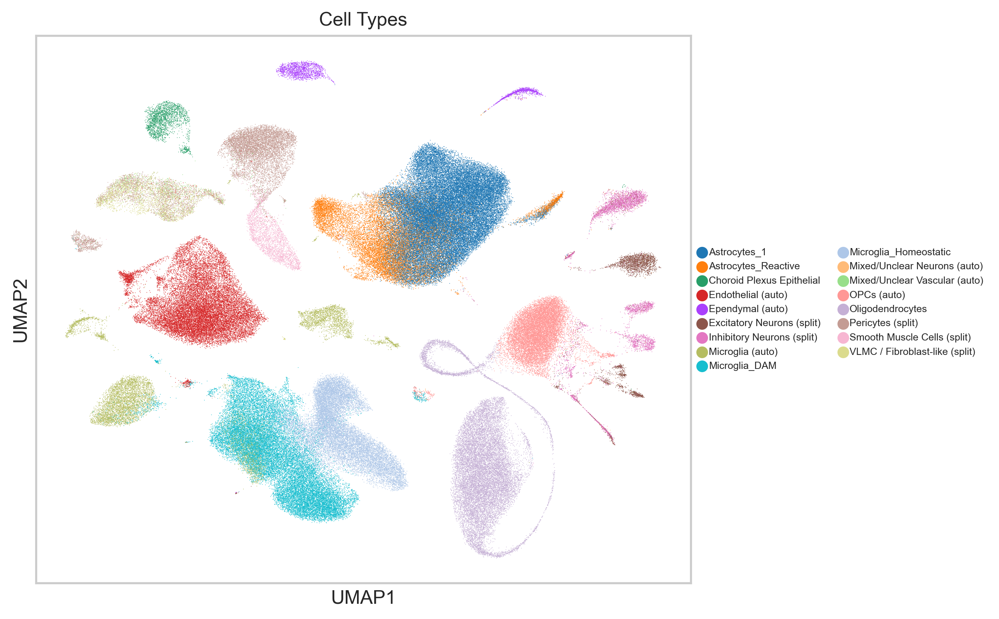

/var/folders/dy/c0t50ltn16zg21tf4dvzq76m0000gn/T/ipykernel_53583/1192524082.py:38: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(adata_fixed, color="condition", title="WT vs 5xFAD (integration check)",


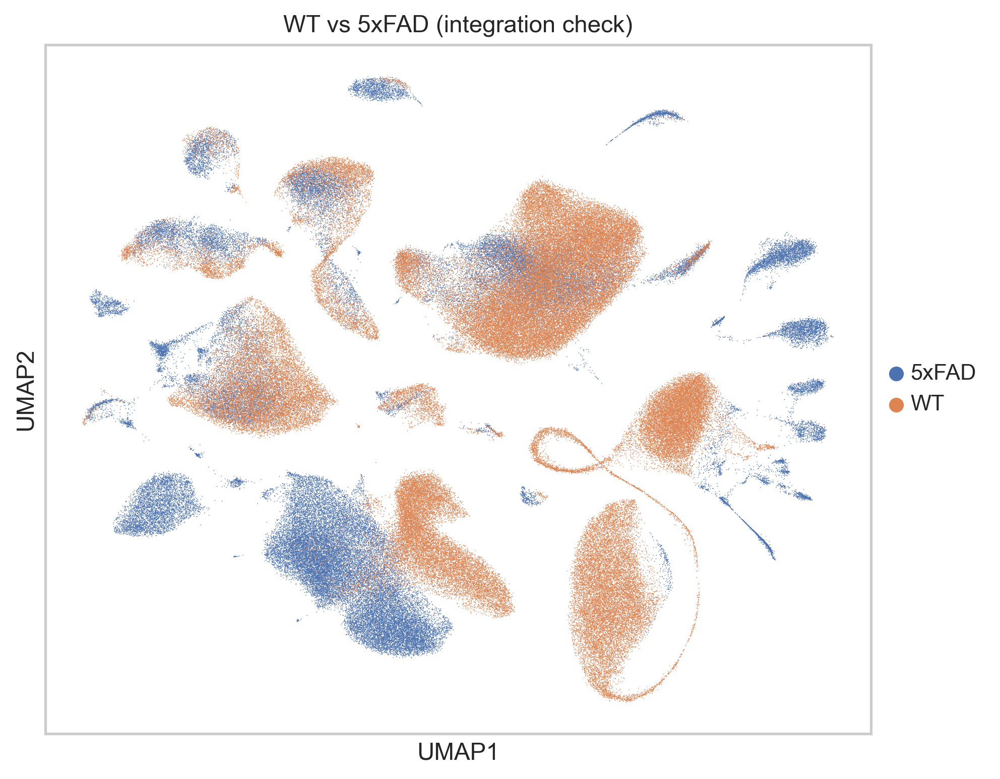

/var/folders/dy/c0t50ltn16zg21tf4dvzq76m0000gn/T/ipykernel_53583/1192524082.py:40: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(adata_fixed, color="timepoint_group", title="WT / 5mo / 9mo",


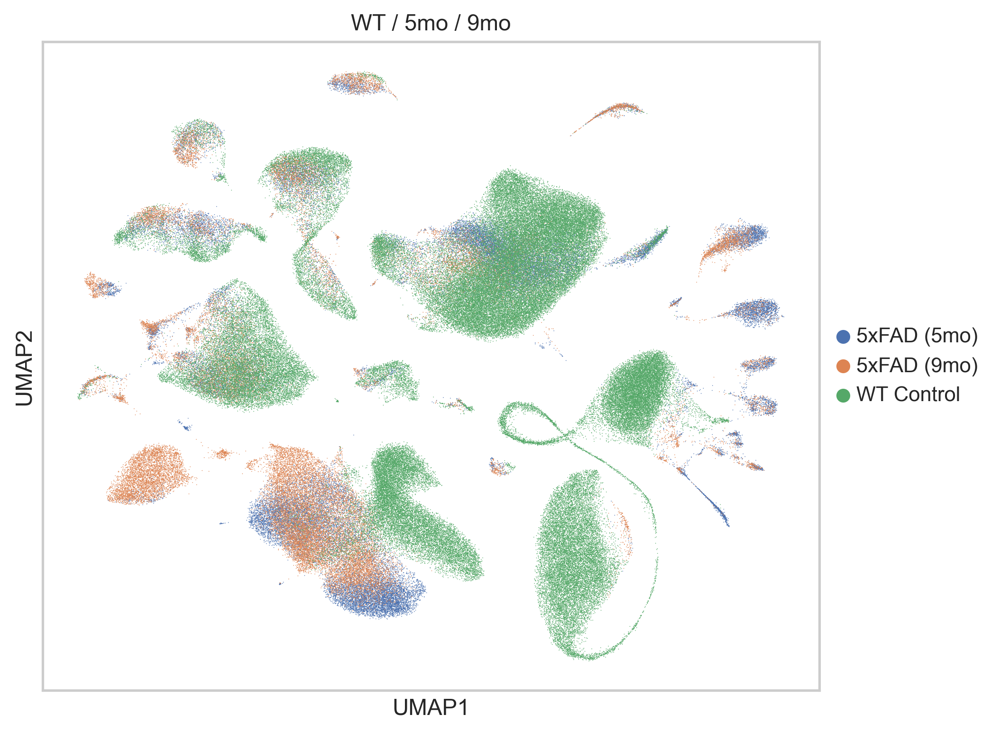

categories: Astrocytes_1, Astrocytes_Reactive, Choroid Plexus Epithelial, etc.
var_group_labels: Microglia, Astrocytes, Oligodendrocytes, etc.


/var/folders/dy/c0t50ltn16zg21tf4dvzq76m0000gn/T/ipykernel_53583/1192524082.py:63: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.dotplot(adata_plot, marker_panel, groupby="full_cell_type", standard_scale="var",


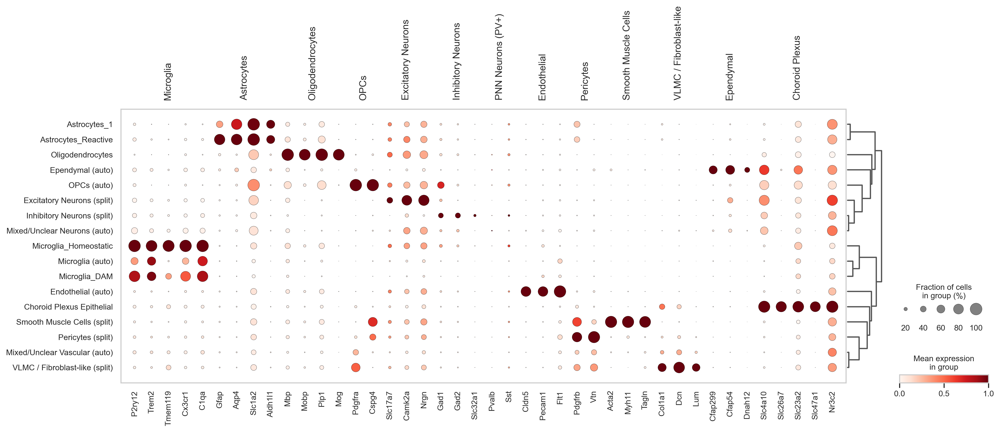

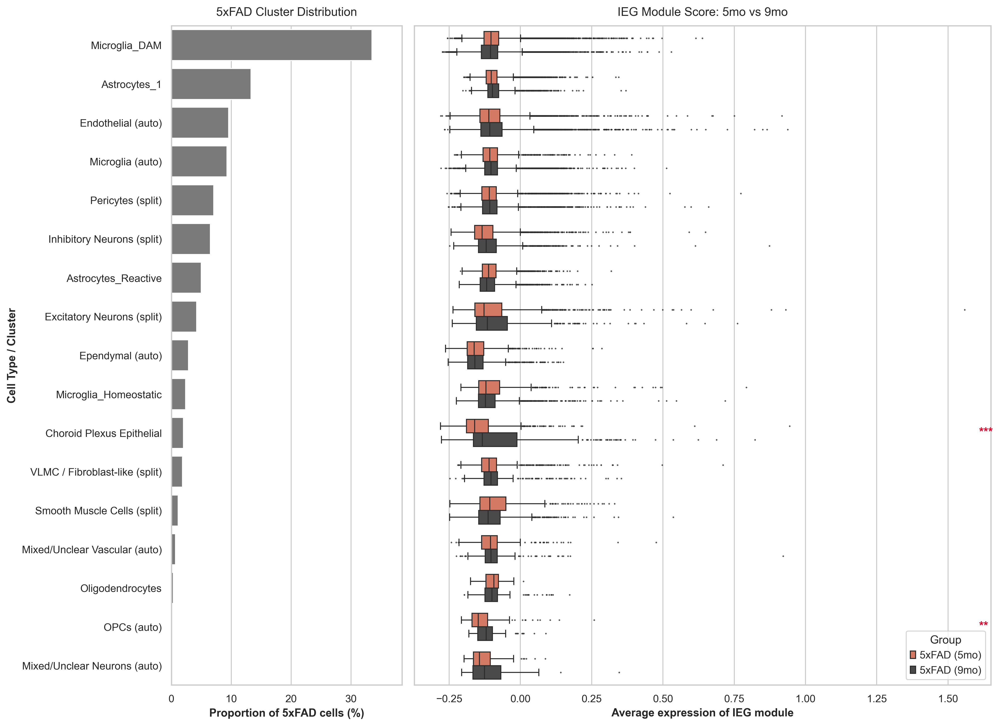

  Saved Figure5A_IEG_5mo_vs_9mo.png


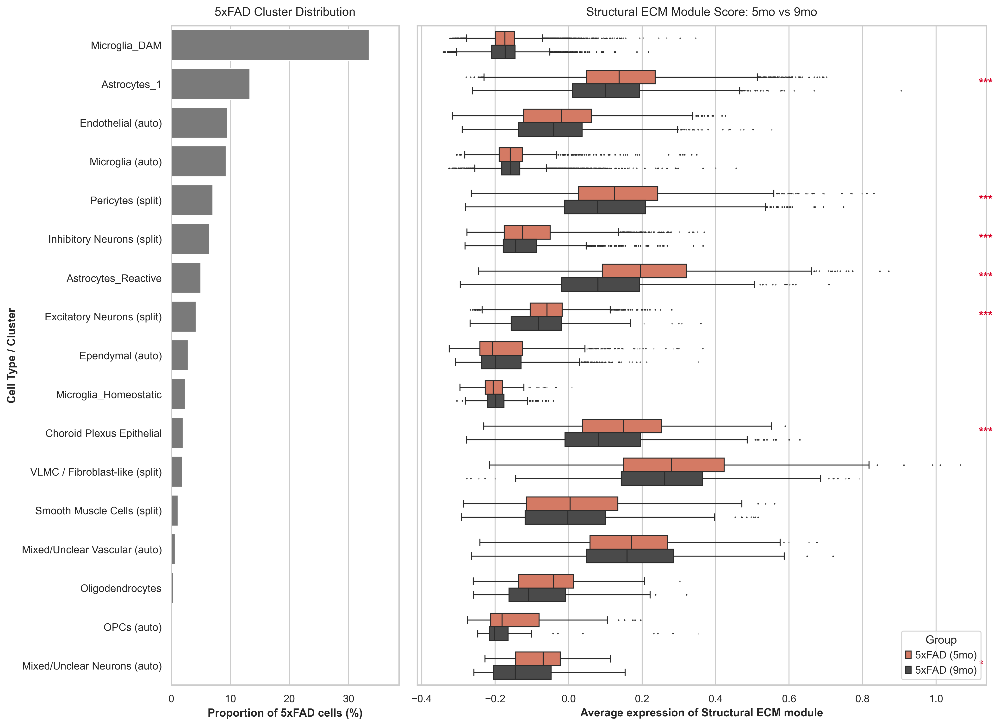

  Saved Figure5B_ECM_Structural_5mo_vs_9mo.png


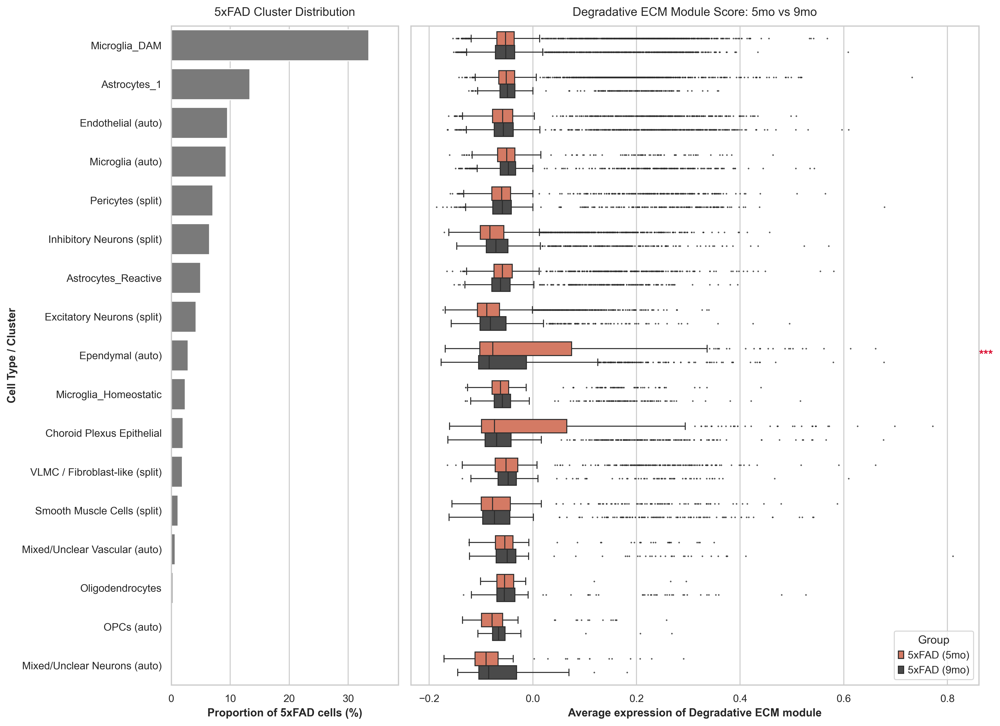

  Saved Figure5C_ECM_Degradative_5mo_vs_9mo.png


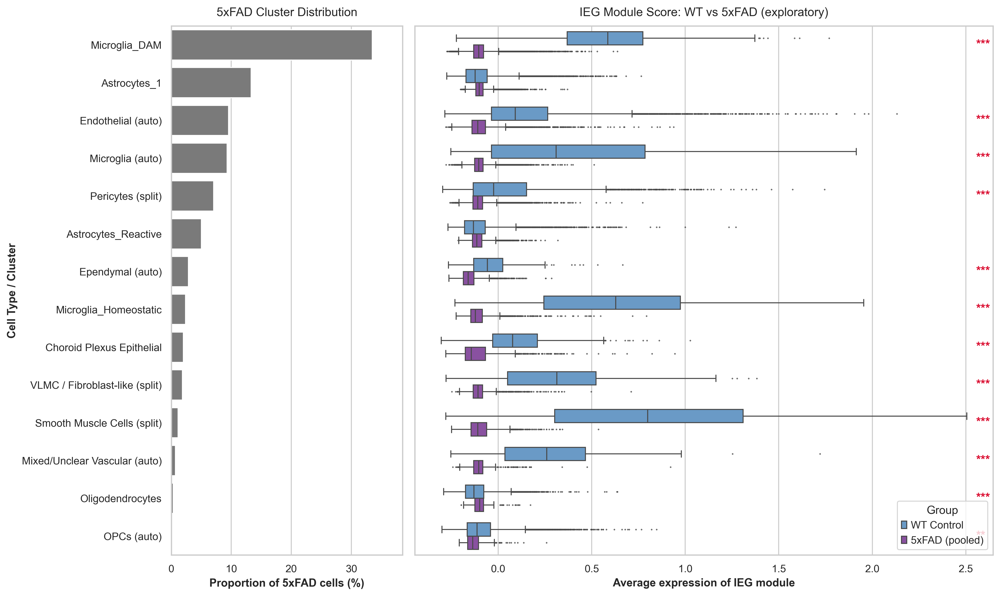

  Saved Figure6A_IEG_WT_vs_5xFAD.png


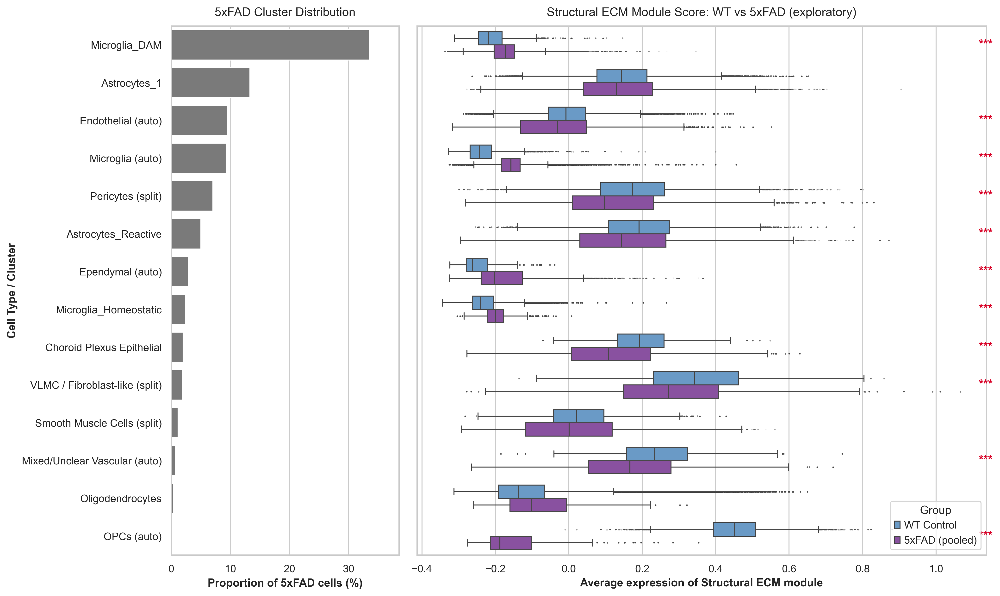

  Saved Figure6B_ECM_Structural_WT_vs_5xFAD.png


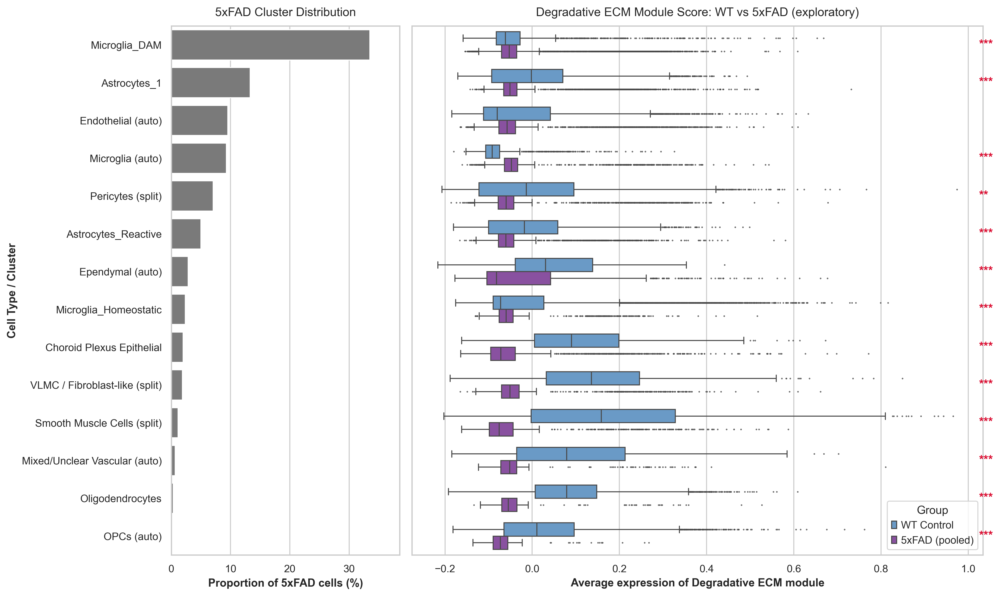

  Saved Figure6C_ECM_Degradative_WT_vs_5xFAD.png

Complete: all 6 figures saved. This is the final step in the pipeline.


In [9]:
#!/usr/bin/env python
# coding: utf-8
#
# 13_generate_all_figures.py
# [VERIFIED: replot_umap_and_dotplot.py + make_six_figures.py, merged, with
# the choroid plexus rename applied defensively]
#
# INPUT:  5xFAD_WT_Combined_Labeled.h5ad
# OUTPUT: Figures 1-4 (UMAPs + dotplot) and Figure 5A-C / 6A-C (module score panels)

import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

sc.set_figure_params(dpi=150, figsize=(7, 6), frameon=True, facecolor="white")
sns.set_theme(style="whitegrid", font_scale=0.95)

OLD_LABEL = "PNN Neurons (PV+) (auto)"
NEW_LABEL = "Choroid Plexus Epithelial"

adata_fixed = sc.read_h5ad("5xFAD_WT_Combined_Labeled.h5ad")
if "X_umap" not in adata_fixed.obsm:
    raise RuntimeError("No X_umap found -- run 07_make_umap.py first.")

adata_fixed.obs["full_cell_type"] = adata_fixed.obs["full_cell_type"].astype(str)
n_old = (adata_fixed.obs["full_cell_type"] == OLD_LABEL).sum()
if n_old > 0:
    adata_fixed.obs["full_cell_type"] = adata_fixed.obs["full_cell_type"].replace({OLD_LABEL: NEW_LABEL})
    adata_fixed.write("5xFAD_WT_Combined_Labeled.h5ad", compression=None)

# --- Figures 1-3: UMAPs ---
sc.pl.umap(adata_fixed, color="full_cell_type", legend_loc="right margin", legend_fontsize=6,
           title="Cell Types", save="_figure1_by_celltype.png")
sc.pl.umap(adata_fixed, color="condition", title="WT vs 5xFAD (integration check)",
           save="_figure2_by_condition.png")
sc.pl.umap(adata_fixed, color="timepoint_group", title="WT / 5mo / 9mo",
           save="_figure3_by_timepoint.png")

# --- Figure 4: marker dotplot ---
plot_types = adata_fixed.obs[~adata_fixed.obs["full_cell_type"].isin(["nan", "None", "Other", "Unknown"])].copy()
adata_plot = adata_fixed[plot_types.index].copy()
marker_panel = {
    "Microglia": ["P2ry12", "Trem2", "Tmem119", "Cx3cr1", "C1qa"],
    "Astrocytes": ["Gfap", "Aqp4", "Slc1a2", "Aldh1l1"],
    "Oligodendrocytes": ["Mbp", "Mobp", "Plp1", "Mog"],
    "OPCs": ["Pdgfra", "Cspg4"],
    "Excitatory Neurons": ["Slc17a7", "Camk2a", "Nrgn"],
    "Inhibitory Neurons": ["Gad1", "Gad2", "Slc32a1"],
    "PNN Neurons (PV+)": ["Pvalb", "Sst"],
    "Endothelial": ["Cldn5", "Pecam1", "Flt1"],
    "Pericytes": ["Pdgfrb", "Vtn"],
    "Smooth Muscle Cells": ["Acta2", "Myh11", "Tagln"],
    "VLMC / Fibroblast-like": ["Col1a1", "Dcn", "Lum"],
    "Ependymal": ["Cfap299", "Cfap54", "Dnah12"],
    "Choroid Plexus": ["Slc4a10", "Slc26a7", "Slc23a2", "Slc47a1", "Nr3c2"],
}
marker_panel = {c: [g for g in gs if g in adata_plot.var_names] for c, gs in marker_panel.items()}
marker_panel = {c: gs for c, gs in marker_panel.items() if gs}
sc.pl.dotplot(adata_plot, marker_panel, groupby="full_cell_type", standard_scale="var",
              dendrogram=True, save="_figure4_marker_validation.png")

# --- Figures 5 & 6: module score panels ---
plot_obs = adata_fixed.obs[~adata_fixed.obs["full_cell_type"].astype(str).isin(["nan", "None", "Other", "Unknown"])].copy()
plot_obs["genotype_group"] = np.where(plot_obs["timepoint_group"] == "WT Control", "WT Control", "5xFAD (pooled)")
fad_obs = plot_obs[plot_obs["timepoint_group"].astype(str).str.contains("5xFAD")].copy()
cluster_counts = fad_obs["full_cell_type"].value_counts(normalize=True) * 100
prop_df = pd.DataFrame({"cluster": cluster_counts.index, "proportion": cluster_counts.values})


def cohens_d(a, b):
    a, b = np.asarray(a), np.asarray(b)
    n1, n2 = len(a), len(b)
    pooled_sd = np.sqrt(((n1 - 1) * a.var(ddof=1) + (n2 - 1) * b.var(ddof=1)) / (n1 + n2 - 2))
    return (a.mean() - b.mean()) / pooled_sd if pooled_sd > 0 else np.nan


def get_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def run_stats(obs_df, score_col, group_col, group_a, group_b, min_n=10, min_cohens_d=0.2):
    results = []
    for ct in obs_df["full_cell_type"].unique():
        df_ct = obs_df[obs_df["full_cell_type"] == ct]
        sa = df_ct.loc[df_ct[group_col] == group_a, score_col]
        sb = df_ct.loc[df_ct[group_col] == group_b, score_col]
        p_val, d = np.nan, np.nan
        if len(sa) > min_n and len(sb) > min_n:
            _, p_val = mannwhitneyu(sa, sb, alternative="two-sided")
            d = cohens_d(sb.values, sa.values)
        results.append({"cell_type": ct, "p_val": p_val, "cohens_d": d})
    res_df = pd.DataFrame(results)
    res_df["fdr"] = multipletests(res_df["p_val"].fillna(1.0), method="fdr_bh")[1]
    res_df["sig"] = res_df["fdr"].apply(get_stars)
    res_df.loc[res_df["cohens_d"].abs() < min_cohens_d, "sig"] = "ns"
    return res_df.set_index("cell_type")["sig"].to_dict()


def get_valid_cell_types(obs_df, group_col, groups, min_n=10):
    counts_by_group = obs_df[obs_df[group_col].isin(groups)].groupby(["full_cell_type", group_col], observed=True).size().unstack(fill_value=0)
    for g in groups:
        if g not in counts_by_group.columns:
            counts_by_group[g] = 0
    return counts_by_group[(counts_by_group[groups] >= min_n).all(axis=1)].index.tolist()


def make_module_figure(score_col, xlabel, title, filename, group_col, group_a, group_b, palette):
    valid_types = get_valid_cell_types(plot_obs, group_col, [group_a, group_b])
    order = [c for c in cluster_counts.index.tolist() if c in valid_types]
    if not order:
        print(f"  WARNING: no valid cell types for {filename} -- skipping.")
        return
    local_prop_df = prop_df[prop_df["cluster"].isin(order)]
    plot_df = plot_obs[plot_obs["full_cell_type"].isin(order) & plot_obs[group_col].isin([group_a, group_b])]
    stat_dict = run_stats(plot_obs, score_col, group_col, group_a, group_b)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, max(6, 0.6 * len(order))), sharey=True, gridspec_kw={"width_ratios": [1, 2.5]})
    sns.barplot(data=local_prop_df, x="proportion", y="cluster", order=order, color="#7A7A7A", ax=ax1)
    ax1.set_xlabel("Proportion of 5xFAD cells (%)", fontsize=11, fontweight="bold")
    ax1.set_ylabel("Cell Type / Cluster", fontsize=11, fontweight="bold")
    ax1.set_title("5xFAD Cluster Distribution", fontsize=12, pad=10)
    ax1.set_xlim(0, max(local_prop_df["proportion"]) * 1.15)

    sns.boxplot(data=plot_df, x=score_col, y="full_cell_type", order=order, hue=group_col,
                hue_order=[group_a, group_b], palette=palette, orient="h", fliersize=0.5,
                linewidth=1.0, width=0.7, ax=ax2)
    x_max = plot_df[score_col].max() + 0.05
    for y_idx, cluster_name in enumerate(order):
        sig_stars = stat_dict.get(cluster_name, "ns")
        if sig_stars != "ns":
            ax2.text(x=x_max, y=y_idx, s=sig_stars, va="center", ha="left", fontsize=12, fontweight="bold", color="#D90429")
    ax2.set_xlabel(xlabel, fontsize=11, fontweight="bold")
    ax2.set_ylabel("")
    ax2.set_title(title, fontsize=12, pad=10)
    ax2.legend(title="Group", loc="lower right", frameon=True, facecolor="white")
    plt.subplots_adjust(wspace=0.08)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()
    print(f"  Saved {filename}")


palette_progression = {"5xFAD (5mo)": "#E76F51", "5xFAD (9mo)": "#4A4A4A"}
palette_genotype = {"WT Control": "#5B9BD5", "5xFAD (pooled)": "#8E44AD"}

make_module_figure("IEG_score", "Average expression of IEG module", "IEG Module Score: 5mo vs 9mo",
                    "Figure5A_IEG_5mo_vs_9mo.png", "timepoint_group", "5xFAD (5mo)", "5xFAD (9mo)", palette_progression)
make_module_figure("ECM_Structural_score", "Average expression of Structural ECM module", "Structural ECM Module Score: 5mo vs 9mo",
                    "Figure5B_ECM_Structural_5mo_vs_9mo.png", "timepoint_group", "5xFAD (5mo)", "5xFAD (9mo)", palette_progression)
make_module_figure("ECM_Degradative_score", "Average expression of Degradative ECM module", "Degradative ECM Module Score: 5mo vs 9mo",
                    "Figure5C_ECM_Degradative_5mo_vs_9mo.png", "timepoint_group", "5xFAD (5mo)", "5xFAD (9mo)", palette_progression)
make_module_figure("IEG_score", "Average expression of IEG module", "IEG Module Score: WT vs 5xFAD (exploratory)",
                    "Figure6A_IEG_WT_vs_5xFAD.png", "genotype_group", "WT Control", "5xFAD (pooled)", palette_genotype)
make_module_figure("ECM_Structural_score", "Average expression of Structural ECM module", "Structural ECM Module Score: WT vs 5xFAD (exploratory)",
                    "Figure6B_ECM_Structural_WT_vs_5xFAD.png", "genotype_group", "WT Control", "5xFAD (pooled)", palette_genotype)
make_module_figure("ECM_Degradative_score", "Average expression of Degradative ECM module", "Degradative ECM Module Score: WT vs 5xFAD (exploratory)",
                    "Figure6C_ECM_Degradative_WT_vs_5xFAD.png", "genotype_group", "WT Control", "5xFAD (pooled)", palette_genotype)

print("\nComplete: all 6 figures saved. This is the final step in the pipeline.")